In [233]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Lectura de datos

# 2. Función de Partición.
Esta funciión, filtra el df por cada una de sus particiones.

In [234]:
# ============================================================================================================
# Función para particionar el DataFrame por un periodo específico. Como entrada toma el DataFrame, el nombre
# de la columna por la cual se va a particionar y el valor del periodo a filtrar y devuelve un DataFrame
# filtrado por el periodo específico.
# ============================================================================================================
def df_partition(df: pd.DataFrame, column: str, periodo) -> pd.DataFrame:
    df_periodo = df[df[column] == periodo].reset_index(drop=True)
    return df_periodo

# 3. Función que realiza la Regresión Logarítmica.

In [235]:
# ============================================================================================================
# Función para realizar regresión logarítmica. Como entrada toma el DataFrame, el nombre del campo origen,
# los nombres de los campos a predecir, el valor del campo origen para el cual se quieren predecir los valores de
# los campos a predecir y devuelve un DataFrame con una nueva fila que contiene el valor del campo origen y los
# valores predichos de los campos a predecir.
# ============================================================================================================
def reg_log(df: pd.DataFrame, campo_origen: str, campo_destino1: str, campo_destino2: str, x: float) -> pd.DataFrame:
# ============================================================================================================
# Longitu del df para calcular promedios y sumas necesarias para la regresión logarítmica.
# ============================================================================================================
    n = len(df)
# ============================================================================================================
# Vector donde se almacenarán los valores predichos de los campos a predecir.
# ============================================================================================================
    y_pred = []
    m_list = []
    b_list = []
# ============================================================================================================
# Bucle que recorre los campos a predecir para calcular los coeficientes de la regresión logarítmica y predecir
# los valores de los campos a predecir para el valor del campo origen dado.
# ============================================================================================================
    for i in [campo_destino1, campo_destino2]:
# ============================================================================================================
# Cálculo de las columnas auxiliares necesarias para la regresión logarítmica y los coeficientes de la
# regresión
# ============================================================================================================
        df['Z'] = np.log(df[campo_origen])
        df['ZY'] = df['Z'] * df[i]
        df['Z2'] = df['Z'] ** 2
# ============================================================================================================
# Variables para el cálculo de los coeficientes de la regresión logarítmica.
# ============================================================================================================
        Z_avg = df['Z'].mean()
        Y_avg = df[i].mean()
        Z2_sum = df['Z2'].sum()
        Z_sum = df['Z'].sum()
        Y_sum = df[i].sum()
        ZY_sum = df['ZY'].sum()

        SSZZ = Z2_sum - (Z_sum ** 2) / n
        SSZY = ZY_sum - (Z_sum * Y_sum) / n
# ============================================================================================================
# Cálculo de los coeficientes de la regresión logarítmica y predicción del valor del campo a predecir para el 
# valor dado del campo origen.
# ============================================================================================================
        m = SSZY / SSZZ
        b = Y_avg - m * Z_avg

        m_list.append(m)
        b_list.append(b)
        y_pred.append(m * np.log(x) + b)

# ============================================================================================================
# Eliminar columnas auxiliares del df original
# ============================================================================================================
    df_original = df.drop(columns=['Z', 'ZY', 'Z2'])

# ============================================================================================================
# Nueva fila: campos usados con valores predichos, el resto NaN
# ============================================================================================================
    nueva_fila = {col: np.nan for col in df_original.columns}
    nueva_fila[campo_origen] = x
    nueva_fila[campo_destino1] = y_pred[0]
    nueva_fila[campo_destino2] = y_pred[1]
# ============================================================================================================
# Concatenar la nueva fila al DataFrame original y devolver el resultado
# ============================================================================================================
    df_result = pd.concat([df_original, pd.DataFrame([nueva_fila])], ignore_index=True)
    return df_result, m_list, b_list

# 4. Función que devuelve el Dataframe origial junto con sus predicciones.

In [236]:
# ============================================================================================================
# Función para utiliza las funciones anteriores para particionar el DataFrame por el campo de partición,
# realizar la regresión logarítmica para cada partición y concatenar los resultados en un nuevo DataFrame.
# Toma como entrada el DataFrame, el nombre del campo origen, el nombre del campo por el cual se va a
# particionar, los nombres de los campos a predecir, el valor del campo origen para el cual se quieren predecir
# los valores de los campos a predecir y devuelve un DataFrame con las filas originales más las filas con los
# valores predichos para cada partición.
# ============================================================================================================
def df_predict(df: pd.DataFrame, campo_origen: str, campo_particionado: str, camp_pred_1: str, camp_pred_2: str, x: float):
# ============================================================================================================
# Crear un nuevo DataFrame vacío con las mismas columnas que el DataFrame original para almacenar los
# resultados.
# ============================================================================================================    
    df_new = pd.DataFrame(columns=list(df.columns))
# ============================================================================================================
# DataFrame para almacenar los valores ajustados por la regresión (originales + predicho).
# ============================================================================================================
    df_reg = pd.DataFrame()
# ============================================================================================================
# Bucle que recorre los valores únicos del campo de partición, realiza la partición del DataFrame, aplica la
# regresión logarítmica y concatena los resultados en el DataFrame final.
# ============================================================================================================
    for i in df[campo_particionado].unique():
# ============================================================================================================
# Crear Dataframe Particionado.
# ============================================================================================================
       df_temp = df_partition(df, campo_particionado, i)
# ============================================================================================================
# Aplicar regresión logarítmica al DataFrame particionado.
# ============================================================================================================
       df_aux, m_list, b_list = reg_log(df_temp, campo_origen, camp_pred_1, camp_pred_2, x)
# ============================================================================================================
# Asignar el valor del campo de partición a la nueva fila con los valores predichos y concatenar el DataFrame
# auxiliar al DataFrame final.
# ============================================================================================================
       df_aux.iloc[-1, df_aux.columns.get_loc(campo_particionado)] = i
       df_new = pd.concat([df_new, df_aux], ignore_index=True)
# ============================================================================================================
# Construir filas con valores ajustados por la regresión para los x originales + el predicho.
# ============================================================================================================
       x_vals = list(df_temp[campo_origen]) + [x]
       reg_rows = pd.DataFrame({
           campo_particionado: i,
           campo_origen: x_vals,
           camp_pred_1: [m_list[0] * np.log(xv) + b_list[0] for xv in x_vals],
           camp_pred_2: [m_list[1] * np.log(xv) + b_list[1] for xv in x_vals],
       })
       df_reg = pd.concat([df_reg, reg_rows], ignore_index=True)
    return df_new, df_reg

# 5. Pruebas

## 5.1. Lectura y Visualización de Datos Originales

In [237]:
df = pd.read_csv('Ventas_Company_H.csv').sort_values(by=['Anio', 'Mes']).reset_index(drop=True)
df.head()

,Anio,Mes,Numero_Total_Ventas,Valor_Total_Ventas
0,2005,1,31870.940650,174918.310181
1,2005,2,37295.094309,206292.028606
2,2005,3,38210.913821,220291.694104
3,2005,4,28489.150407,151573.196578
4,2005,5,37498.452033,131223.848292


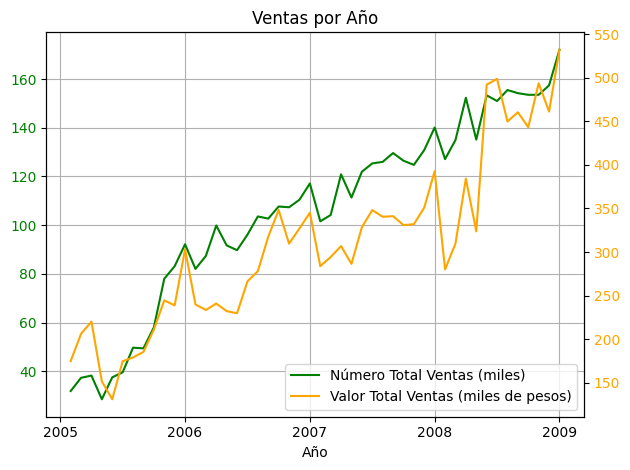

In [238]:
from matplotlib.ticker import MaxNLocator, FuncFormatter

miles = FuncFormatter(lambda x, _: f'{x/1000:.0f}')

fig, ax1 = plt.subplots()

x_time = df['Anio'] + df['Mes']/12

ax1.plot(x_time, df['Numero_Total_Ventas'], c='green', label='Número Total Ventas (miles)')
ax1.set_xlabel('Año')
ax1.tick_params(axis='y', labelcolor='green')
ax1.yaxis.set_major_formatter(miles)

ax2 = ax1.twinx()
ax2.plot(x_time, df['Valor_Total_Ventas'], c='orange', label='Valor Total Ventas (miles de pesos)')
ax2.tick_params(axis='y', labelcolor='orange')
ax2.yaxis.set_major_formatter(miles)

ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.title('Ventas por Año')
plt.tight_layout()
ax1.grid(True, axis='both')
plt.show()

## 5.2. Predicción de los valores para 2009 mediante la regresión logarítmica.

In [245]:
df_new, df_reg = df_predict(df, 'Anio', 'Mes', 'Numero_Total_Ventas', 'Valor_Total_Ventas', 2009)

/var/folders/gh/m_mcn3y96_d4tqh_jyd_901w0000gn/T/ipykernel_1128/1107429067.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_new = pd.concat([df_new, df_aux], ignore_index=True)


## 5.3. Visualización de un mes.

In [246]:
df_prueba = df_partition(df_new, 'Mes', 3)
df_prueba_reg = df_partition(df_reg, 'Mes', 3)
df_prueba_reg.head()

,Mes,Anio,Numero_Total_Ventas,Valor_Total_Ventas
0,3,2005,48306.022660,204434.387789
1,3,2006,84660.495777,260230.032300
2,3,2007,120996.850542,315997.869363
3,3,2008,157315.105005,371737.926680
4,3,2009,193615.277189,427450.231913


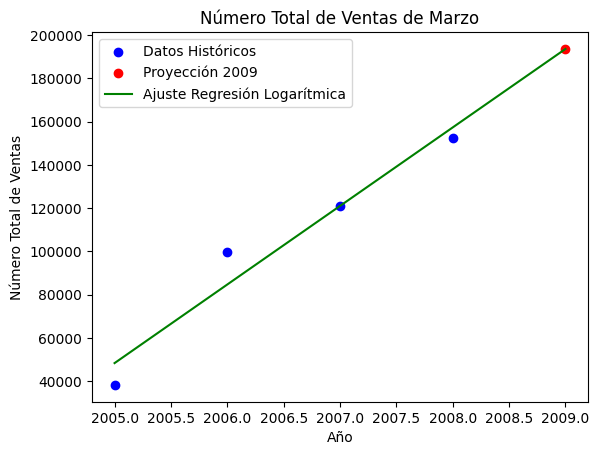

In [249]:
plt.scatter(df_prueba[df_prueba.Anio < 2009]['Anio'], df_prueba[df_prueba.Anio < 2009]['Numero_Total_Ventas'], c = 'blue', label='Datos Históricos')
plt.scatter(df_prueba[df_prueba.Anio == 2009]['Anio'], df_prueba[df_prueba.Anio == 2009]['Numero_Total_Ventas'], c = 'red', label='Proyección 2009')
plt.plot(df_prueba_reg['Anio'], df_prueba_reg['Numero_Total_Ventas'], c='green', label='Ajuste Regresión Logarítmica')
plt.xlabel('Año')
plt.ylabel('Número Total de Ventas')
plt.title('Número Total de Ventas de Marzo')
plt.legend()
plt.show()

## 5.4. Visualización de todo el 2009 junto con los datos históricos.

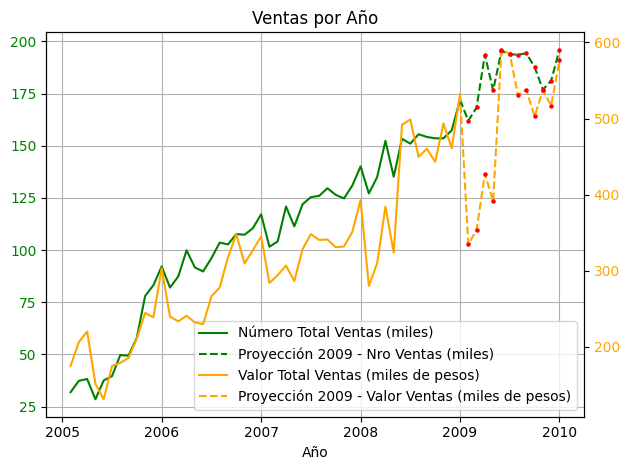

In [252]:
from matplotlib.ticker import MaxNLocator, FuncFormatter

miles = FuncFormatter(lambda x, _: f'{x/1000:.0f}')

fig, ax1 = plt.subplots()

x_time = df['Anio'] + df['Mes']/12

ax1.plot(x_time, df['Numero_Total_Ventas'], c='green', label='Número Total Ventas (miles)')
ax1.set_xlabel('Año')
ax1.tick_params(axis='y', labelcolor='green')
ax1.yaxis.set_major_formatter(miles)

ax2 = ax1.twinx()
ax2.plot(x_time, df['Valor_Total_Ventas'], c='orange', label='Valor Total Ventas (miles de pesos)')
ax2.tick_params(axis='y', labelcolor='orange')
ax2.yaxis.set_major_formatter(miles)

df_2009 = df_new[df_new['Anio'] == 2009].sort_values('Mes')
x_2009 = df_2009['Anio'] + df_2009['Mes']/12

x_bridge_1 = pd.concat([x_time.iloc[[-1]], x_2009])
y_bridge_1_nv = pd.concat([df['Numero_Total_Ventas'].iloc[[-1]], df_2009['Numero_Total_Ventas']])
y_bridge_1_vv = pd.concat([df['Valor_Total_Ventas'].iloc[[-1]], df_2009['Valor_Total_Ventas']])

ax1.plot(x_bridge_1, y_bridge_1_nv, c='green', linestyle='--', label='Proyección 2009 - Nro Ventas (miles)')
ax2.plot(x_bridge_1, y_bridge_1_vv, c='orange', linestyle='--', label='Proyección 2009 - Valor Ventas (miles de pesos)')
ax1.scatter(x_2009, df_2009['Numero_Total_Ventas'], c='red', s=5, zorder=5)
ax2.scatter(x_2009, df_2009['Valor_Total_Ventas'], c='red', s=5, zorder=5)

ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.title('Ventas por Año')
plt.tight_layout()
ax1.grid(True, axis='both')
plt.show()